In [135]:
import pandas as pd # Manipulación y análisis de datos tabulares (filas y columnas).
import numpy as np # Operaciones numéricas y matriciales.
import seaborn as sns # Visualización estadística de datos.
import matplotlib.pyplot as plt # Creación de gráficos y visualizaciones.

# Matplotlib es una herramienta versátil para crear gráficos desde cero,
# mientras que Seaborn simplifica la creación de gráficos estadísticos.
from sklearn.decomposition import PCA # Implementación del Análisis de Componentes Principales (PCA).
from sklearn.preprocessing import StandardScaler # Estandarización de datos para análisis estadísticos.

# ACP

In [136]:
# Cargamos el conjunto de datos
df = sns.load_dataset("penguins")

# Visualizamos las primeras filas
print(df.head())

# Guardamos una copia del df original
df_original = df.copy()

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [137]:
# Eliminamos las variables categóricas: 'species', 'island', 'sex' del DataFrame
df = df.drop(['species', 'island', 'sex'], axis=1)

In [138]:
# Eliminamos los NAN
df.dropna(inplace=True)

In [139]:
# Genera una lista con los nombres de las variables
variables = list(df)
print(variables)

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


In [140]:
# Calcula las estadísticas descriptivas para cada variable y crea un DataFrame con los resultados.
estadisticos = pd.DataFrame({
    'Mínimo': df[variables].min(),
    'Percentil 25': df[variables].quantile(0.25),
    'Mediana': df[variables].median(),
    'Percentil 75': df[variables].quantile(0.75),
    'Media': df[variables].mean(),
    'Máximo': df[variables].max(),
    'Desviación Estándar': df[variables].std(),
    'Varianza': df[variables].var(),
    'Coeficiente de Variación': (df[variables].std() / df[variables].mean()),
    'Datos Perdidos': df[variables].isna().sum()  # Cuenta los valores NaN por variable.
})
display(estadisticos.style.format("{:.2f}"))

,Mínimo,Percentil 25,Mediana,Percentil 75,Media,Máximo,Desviación Estándar,Varianza,Coeficiente de Variación,Datos Perdidos
bill_length_mm,32.10,39.23,44.45,48.50,43.92,59.60,5.46,29.81,0.12,0.00
bill_depth_mm,13.10,15.60,17.30,18.70,17.15,21.50,1.97,3.90,0.12,0.00
flipper_length_mm,172.00,190.00,197.00,213.00,200.92,231.00,14.06,197.73,0.07,0.00
body_mass_g,2700.00,3550.00,4050.00,4750.00,4201.75,6300.00,801.95,643131.08,0.19,0.00


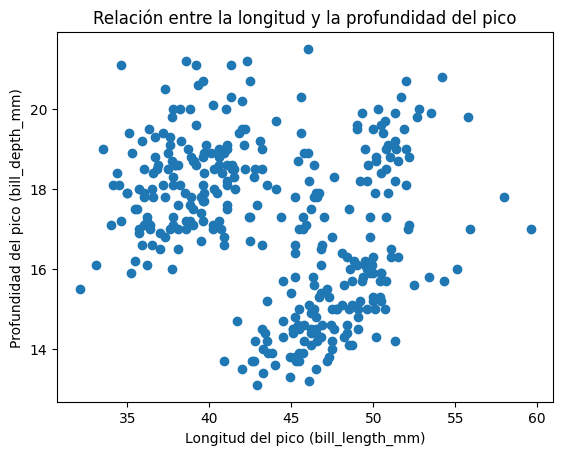

In [141]:
plt.scatter(df['bill_length_mm'], df['bill_depth_mm'])

plt.title("Relación entre la longitud y la profundidad del pico")
plt.xlabel("Longitud del pico (bill_length_mm)")
plt.ylabel("Profundidad del pico (bill_depth_mm)")

plt.show()

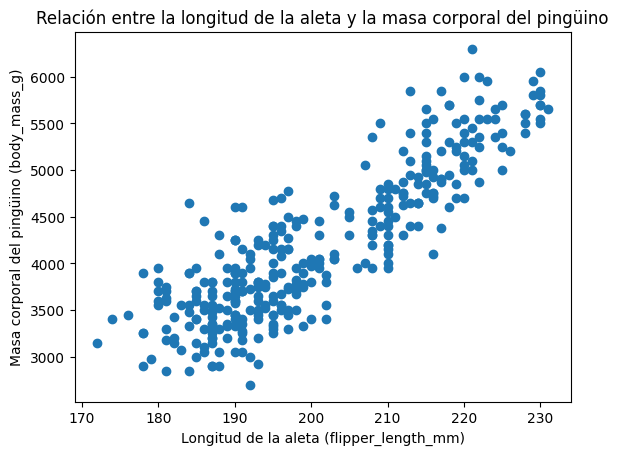

In [142]:
plt.scatter(df['flipper_length_mm'], df['body_mass_g'])

plt.title("Relación entre la longitud de la aleta y la masa corporal del pingüino")
plt.xlabel("Longitud de la aleta (flipper_length_mm)")
plt.ylabel("Masa corporal del pingüino (body_mass_g)")

plt.show()

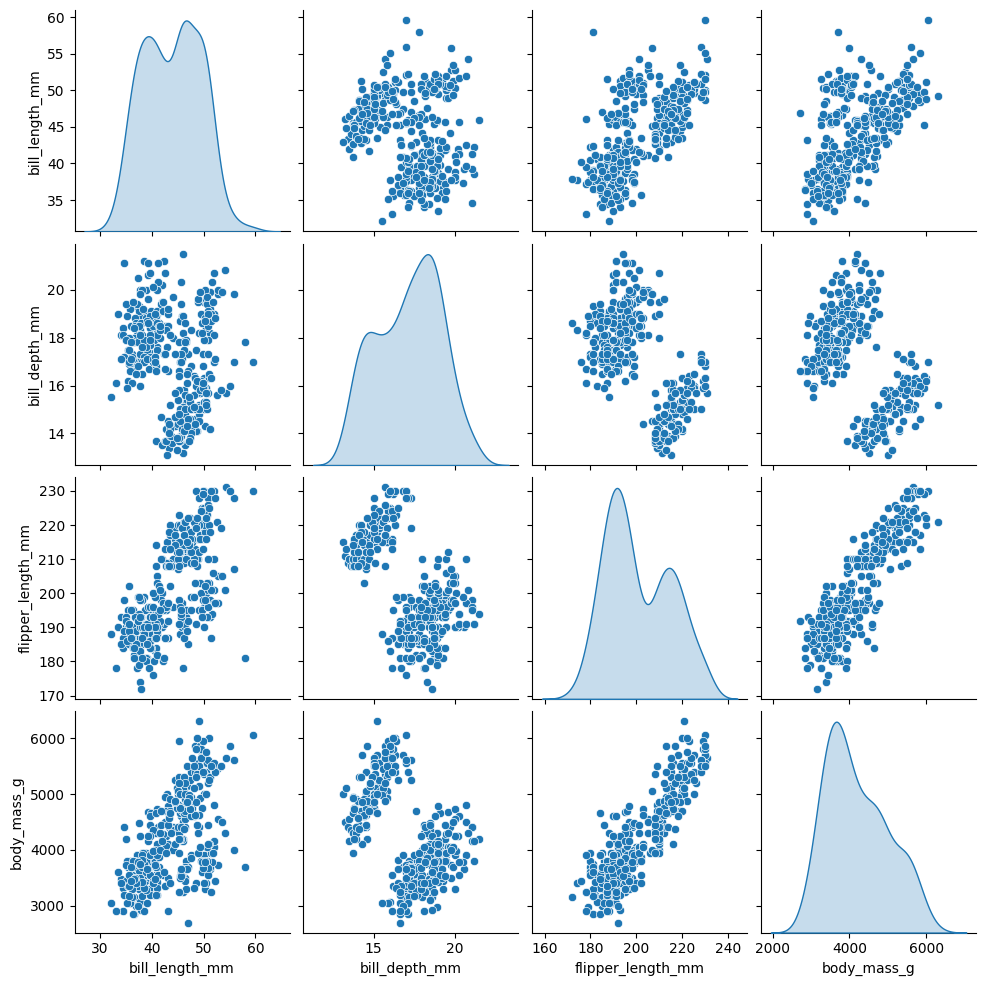

In [143]:
sns.pairplot(df, diag_kind="kde")

<Axes: >

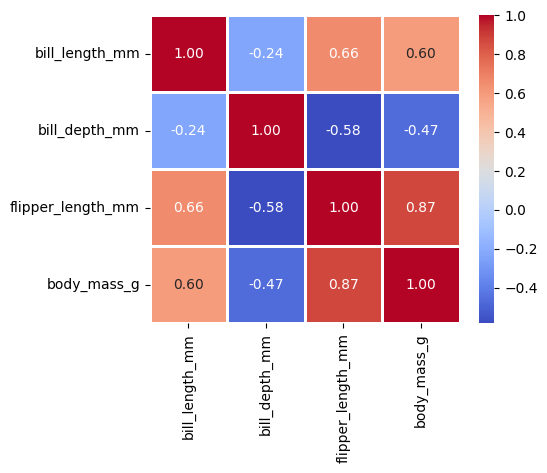

In [144]:
# Calcula y representación de la matriz de correlación entre las variables
R = df.corr()

# Crea una nueva figura de tamaño 10x8 pulgadas para el gráfico.
plt.figure(figsize=(5, 4))

# Genera un mapa de calor (heatmap) de la matriz de correlación 'R' utilizando Seaborn.
sns.heatmap(R, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.8)

In [145]:
# Estandarizamos los datos
df_std = pd.DataFrame(
    StandardScaler().fit_transform(df),  # Datos estandarizados
    columns=['{}_z'.format(variable) for variable in variables],  # Nombres de columnas estandarizadas
    index=df.index  # Índices (etiquetas de filas) del DataFrame
)
display(df_std.style.format("{:.2f}"))

,bill_length_mm_z,bill_depth_mm_z,flipper_length_mm_z,body_mass_g_z
0,-0.88,0.79,-1.42,-0.56
1,-0.81,0.13,-1.06,-0.50
2,-0.66,0.43,-0.42,-1.19
4,-1.32,1.09,-0.56,-0.94
5,-0.85,1.75,-0.78,-0.69
6,-0.92,0.33,-1.42,-0.72
7,-0.87,1.24,-0.42,0.59
8,-1.80,0.48,-0.56,-0.91
9,-0.35,1.55,-0.78,0.06
10,-1.12,-0.03,-1.06,-1.13


In [146]:
# Creamos una instancia de Análisis de Componentes Principales (ACP)
# Definimos que el número máximo de componentes principales sea 4
pca = PCA(n_components=4)

# Aplicamos el Análisis de Componentes Principales (ACP) a los datos estandarizados
fit = pca.fit(df_std)
display(fit)

# Obtener los autovalores asociados a cada componente principal.
autovalores = fit.explained_variance_

# Obtener la varianza explicada por cada componente principal como un porcentaje de la varianza total.
var_explicada = fit.explained_variance_ratio_*100

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [147]:
# Calcular la varianza explicada acumulada a medida que se agregan cada componente principal.
var_acumulada = np.cumsum(var_explicada)

# Crear un DataFrame de pandas con los datos anteriores y establecer índice.
data = {'Autovalores': autovalores, 'Variabilidad Explicada': var_explicada, 'Variabilidad Acumulada': var_acumulada}
tabla = pd.DataFrame(data, index=['Componente {}'.format(i) for i in range(1, fit.n_components_+1)])

# Imprimir la tabla
display(tabla.style.format("{:.2f}"))

,Autovalores,Variabilidad Explicada,Variabilidad Acumulada
Componente 1,2.76,68.84,68.84
Componente 2,0.77,19.31,88.16
Componente 3,0.37,9.13,97.29
Componente 4,0.11,2.71,100.00


In [148]:
from FuncionesMineria3 import *

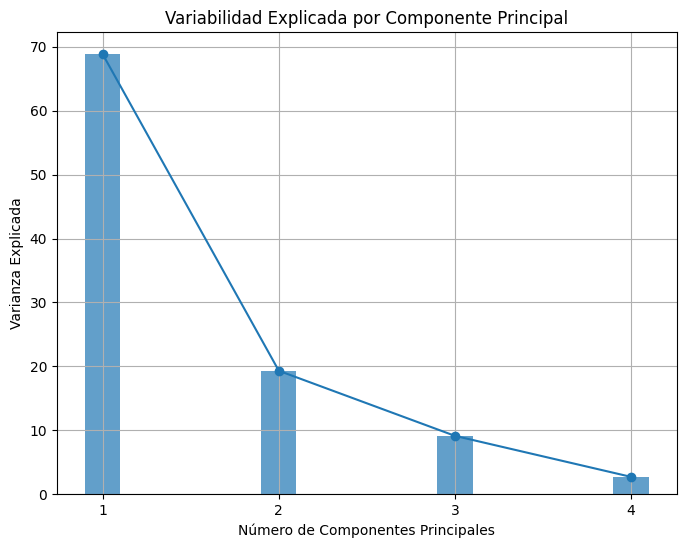

In [149]:
plot_varianza_explicada(var_explicada, fit.n_components_)

In [150]:
# Crea una instancia de ACP con las dos primeras componentes que nos interesan y aplicar a los datos.
n_components = 2
pca = PCA(n_components)
fit = pca.fit(df_std)

# Obtener los autovalores asociados a cada componente principal.
autovalores = fit.explained_variance_

# Obtener los autovectores asociados a cada componente principal y transponerlos.
autovectores = pd.DataFrame(pca.components_.T,
                            columns = ['Autovector {}'.format(i) for i in range(1, fit.n_components_+1)],
                            index = ['{}_z'.format(variable) for variable in variables])
display(autovectores.style.format("{:.2f}"))

,Autovector 1,Autovector 2
bill_length_mm_z,0.46,0.60
bill_depth_mm_z,-0.40,0.80
flipper_length_mm_z,0.58,0.00
body_mass_g_z,0.55,0.08


In [151]:
autovalores = fit.explained_variance_  # shape (2,)
var_explicada = fit.explained_variance_ratio_  # shape (2,)
var_acumulada = np.cumsum(var_explicada)  # shape (2,)

data = {'Autovalores': autovalores, 'Variabilidad Explicada': var_explicada, 
        'Variabilidad Acumulada': var_acumulada}
index = ['Componente {}'.format(i) for i in range(1, fit.n_components_+1)]
tabla = pd.DataFrame(data, index=index)
display(tabla.style.format("{:.2f}"))

,Autovalores,Variabilidad Explicada,Variabilidad Acumulada
Componente 1,2.76,0.69,0.69
Componente 2,0.77,0.19,0.88


<Axes: xlabel='PC1', ylabel='PC2'>

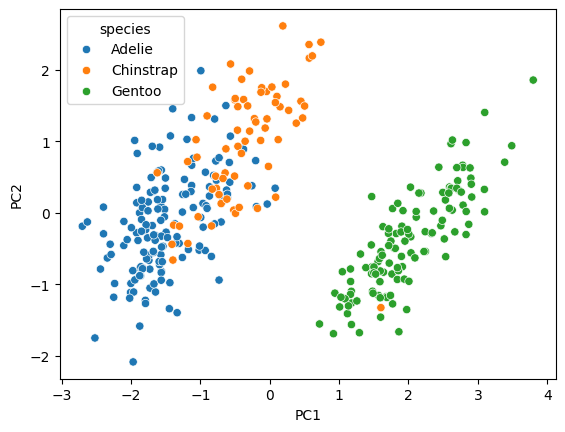

In [152]:
scores = pd.DataFrame(pca.transform(df_std), columns=['PC1', 'PC2'])
scores['species'] = df_original.species  # Añade columna species
sns.scatterplot(data=scores, x='PC1', y='PC2', hue='species')

In [153]:
scores.groupby('species')['PC1'].mean()

species
Adelie      -1.459418
Chinstrap   -0.342267
Gentoo       2.009063
Name: PC1, dtype: float64

# Clústering

### Clústering Jerárquico

In [215]:
!pip install --upgrade scipy

In [216]:
df = df_original.copy()

In [217]:
# Eliminamos las variables categóricas: 'species', 'island', 'sex' del DataFrame
df = df.drop(['island', 'sex'], axis=1)

In [218]:
# Eliminamos los NAN
df.dropna(inplace=True)
df.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,39.1,18.7,181.0,3750.0
1,Adelie,39.5,17.4,186.0,3800.0
2,Adelie,40.3,18.0,195.0,3250.0
4,Adelie,36.7,19.3,193.0,3450.0
5,Adelie,39.3,20.6,190.0,3650.0


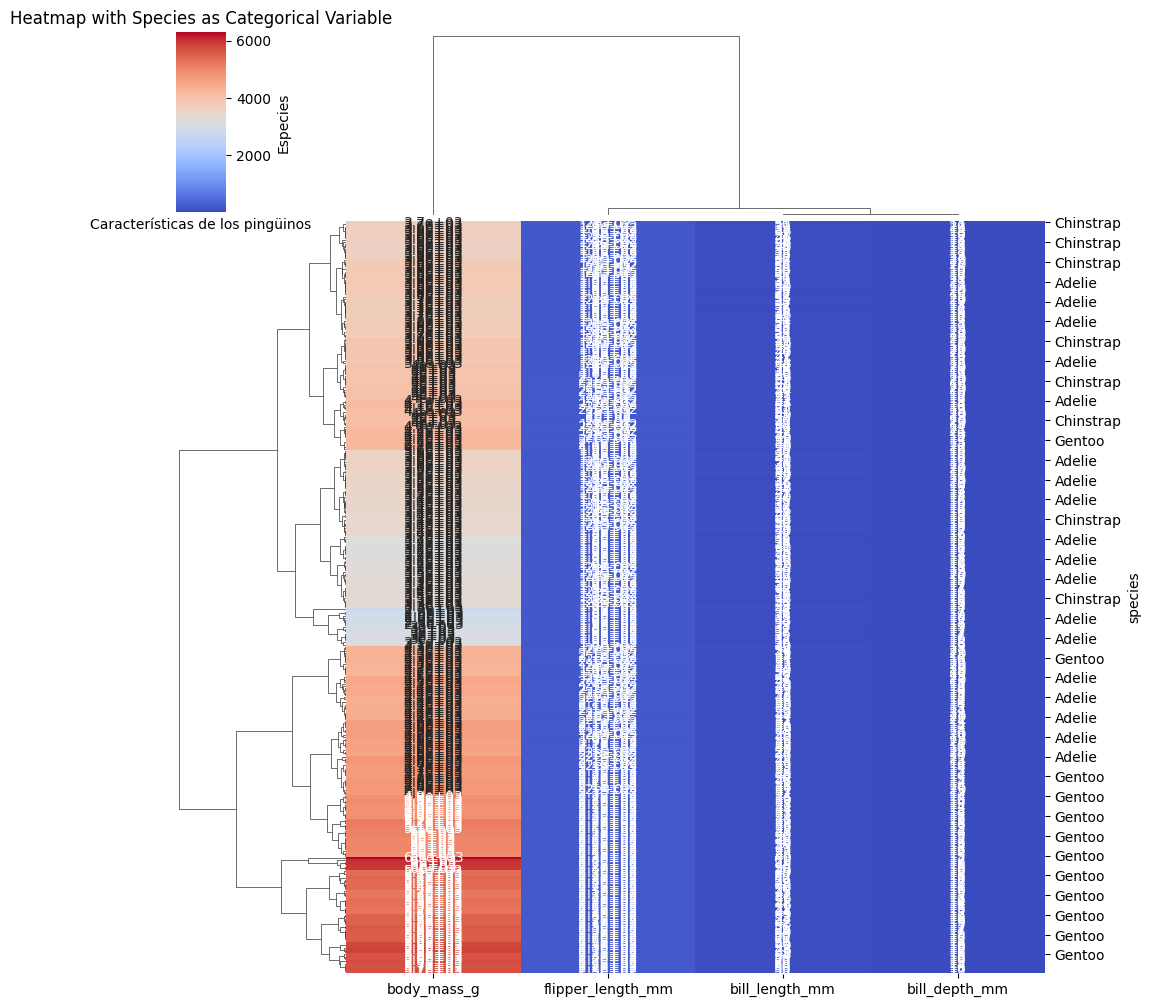

In [219]:
# Set 'PAIS' as the index
df = df.set_index('species')
# Extract the index labels
pengüins_label = df.index

# Create the heatmap
# sns.heatmap(df, cmap='coolwarm', annot=True)
#clustered heatmap
sns.clustermap(df, cmap='coolwarm', annot=True)

# Customize the plot if needed
plt.title('Heatmap with Species as Categorical Variable')
plt.xlabel('Características de los pingüinos')
plt.ylabel('Especies')

# Display the plot
plt.show()

In [220]:
from scipy.spatial import distance

# Calculate the pairwise Euclidean distances
distance_matrix = distance.cdist(df, df, 'euclidean')

# The distance_matrix is a 2D array containing the Euclidean distances
# between all pairs of observations.
print("Distance Matrix:")
distance_small = distance_matrix[:5, :5]
#Index are added to the distance matrix
distance_small = pd.DataFrame(distance_small, index=df.index[:5], columns=df.index[:5])

distance_small_rounded = distance_small.round(2)
print(distance_small_rounded)

Distance Matrix:
species  Adelie  Adelie  Adelie  Adelie  Adelie
species                                        
Adelie     0.00   50.27  500.20  300.25  100.42
Adelie    50.27    0.00  550.07  350.09  150.09
Adelie   500.20  550.07    0.00  200.05  400.04
Adelie   300.25  350.09  200.05    0.00  200.04
Adelie   100.42  150.09  400.04  200.04    0.00


In [221]:
df[:2]

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,39.1,18.7,181.0,3750.0
Adelie,39.5,17.4,186.0,3800.0


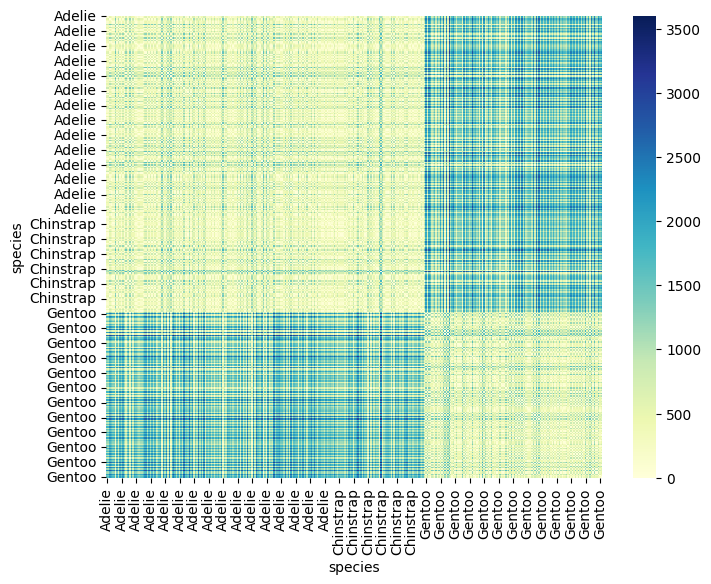

In [222]:
plt.figure(figsize=(8, 6))
df_distance = pd.DataFrame(distance_matrix, index = df.index, columns = df.index)
sns.heatmap(df_distance, annot=False, cmap="YlGnBu", fmt=".1f")
plt.show()

In [223]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the DataFrame to standardize the columns
df_std = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print(df_std)

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0         -0.884499       0.785449          -1.418347    -0.564142
1         -0.811126       0.126188          -1.062250    -0.501703
2         -0.664380       0.430462          -0.421277    -1.188532
3         -1.324737       1.089724          -0.563715    -0.938776
4         -0.847812       1.748985          -0.777373    -0.689020
..              ...            ...                ...          ...
337        0.601305      -1.750171           0.931890     0.903175
338        0.527932      -1.445897           1.003109     0.809516
339        1.188289      -0.735923           1.501644     1.933419
340        0.234440      -1.192335           0.789451     1.246590
341        1.096572      -0.533073           0.860670     1.496346

[342 rows x 4 columns]


In [224]:
# Calculate the pairwise Euclidean distances
distance_std = distance.cdist(df_std, df_std,"euclidean")

print(distance_std[:5,:5].round(2))

[[0.   0.76 1.25 1.08 1.16]
 [0.76 0.   1.   1.28 1.66]
 [1.25 1.   0.   0.98 1.47]
 [1.08 1.28 0.98 0.   0.88]
 [1.16 1.66 1.47 0.88 0.  ]]


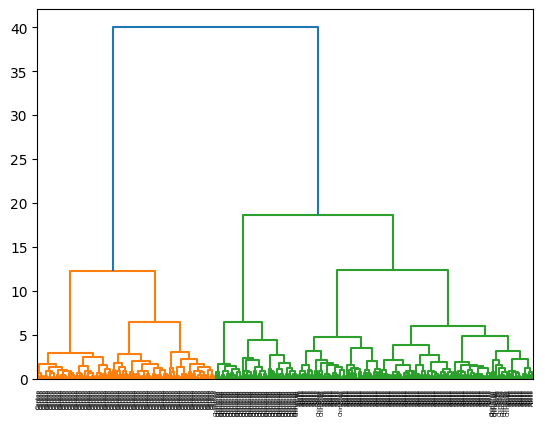

In [225]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import seaborn as sns  # Para colores bonitos

# 1. Ya tienes distance_std (matriz de distancias euclídeas estandarizadas)
# O si quieres recalcular desde df_std:
# from scipy.spatial.distance import pdist
# Z = linkage(df_std, method='ward')  # 'ward' es el más común para euclidiana

# 2. Crea la matriz de linkage (necesaria para dendrogram)
Z = linkage(df_std, method='ward')  # O usa tu distance_std con 'precomputed'

# Create the dendrogram
dendrogram = sch.dendrogram(Z, labels=df.index, leaf_font_size=4, leaf_rotation=90)

# Display the dendrogram
plt.show()


In [230]:
clusters = fcluster(Z, t=15, criterion='distance')
print(f'Clusters encontrados: {len(np.unique(clusters))}')
print(pd.crosstab(clusters, df.index))

Clusters encontrados: 3
col_0  Adelie  Chinstrap  Gentoo
row_0                           
1           0          0     123
2           0         57       0
3         151         11       0


In [232]:
# Asignamos 3 clústers
num_clusters = 3
cluster_assignments = sch.fcluster(Z, num_clusters, criterion='maxclust')

# Mostramos los clusters
print("Asignaciones de clústers:", cluster_assignments)

# Display the dendrogram
plt.show()

Asignaciones de clústers: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 2 2 2 2 2 2 3 2 3 2 2 2 2 2 2 2 2 2 2 2 3 2 3 2 2 2 2 2 2 2 3 2 3 2
 2 2 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 2 3 2 2 3 2 2 2 2 3 2 2 2 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1]


In [233]:
# Create a new column 'Cluster' and assign the 'cluster_assignments' values to it
df['Cluster3'] = cluster_assignments

# Now 'df' contains a new column 'Cluster' with the cluster assignments

print(df["Cluster3"])

species
Adelie    3
Adelie    3
Adelie    3
Adelie    3
Adelie    3
         ..
Gentoo    1
Gentoo    1
Gentoo    1
Gentoo    1
Gentoo    1
Name: Cluster3, Length: 342, dtype: int32


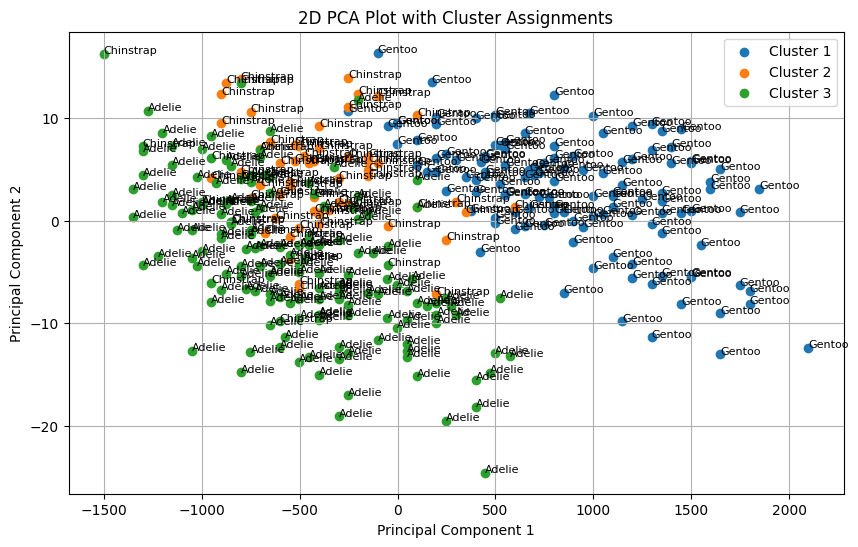

In [234]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming 'df' is your original DataFrame with data
# 'cluster_assignments' contains cluster assignments

# Step 1: Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df)

# Create a new DataFrame for the 2D principal components
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 2: Create a scatter plot with colors for clusters
plt.figure(figsize=(10, 6))

# Loop through unique cluster assignments and plot data points with the same color
for cluster in np.unique(cluster_assignments):
    plt.scatter(df_pca.loc[cluster_assignments == cluster, 'PC1'],
                df_pca.loc[cluster_assignments == cluster, 'PC2'],
                label=f'Cluster {cluster}')
# Add labels to data points
for i, row in df_pca.iterrows():
    plt.text(row['PC1'], row['PC2'], str(df.index[i]), fontsize=8)

plt.title("2D PCA Plot with Cluster Assignments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

### Clústering NO Jerárquico: Agrupamiento K-Means

In [243]:
# Vamos a experimentar con distintos valores de K 
# Para ello hacemos uso del método del codo
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

wcss = []

for k in range(1, 11):  # You can choose a different range of K values
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_std)
    wcss.append(kmeans.inertia_) 

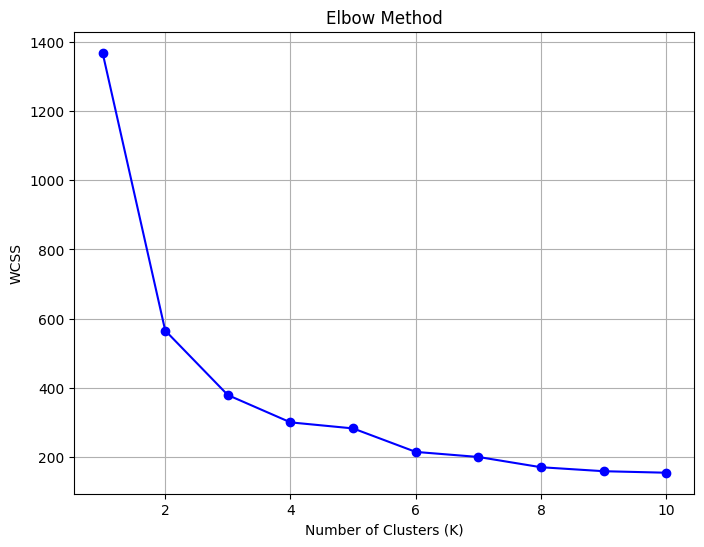

In [244]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [245]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(df_std)
kmeans_cluster_labels = kmeans.labels_
print(kmeans_cluster_labels)

[2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 2 2 2 2 0 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 0 2
 0 2 2 2 0 2 0 2 2 2 2 2 2 2 2 2 0 2 2 2 0 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 0
 2 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 2 0 2 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1]


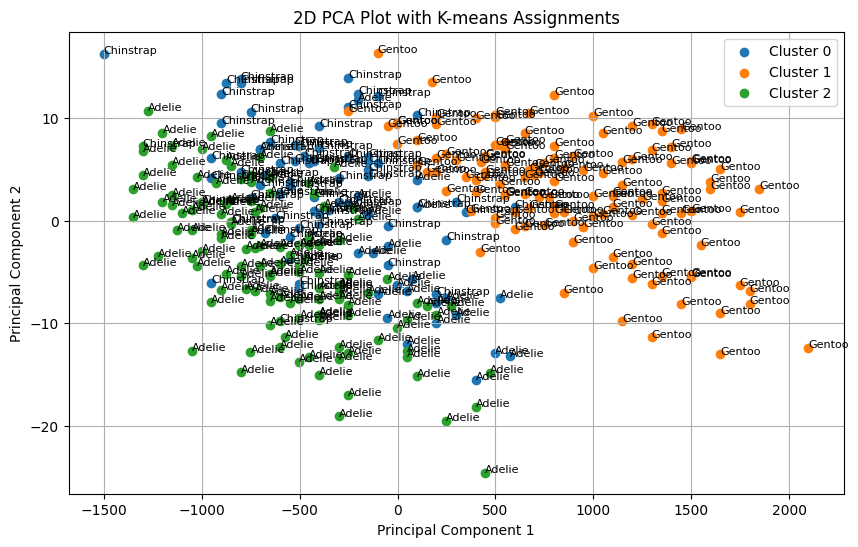

In [246]:
# Step 2: Create a scatter plot with colors for clusters
plt.figure(figsize=(10, 6))

# Loop through unique cluster assignments and plot data points with the same color
for cluster in np.unique(kmeans_cluster_labels):
    plt.scatter(df_pca.loc[kmeans_cluster_labels == cluster, 'PC1'],
                df_pca.loc[kmeans_cluster_labels == cluster, 'PC2'],
                label=f'Cluster {cluster}')
# Add labels to data points
for i, row in df_pca.iterrows():
    plt.text(row['PC1'], row['PC2'], str(df.index[i]), fontsize=8)

plt.title("2D PCA Plot with K-means Assignments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

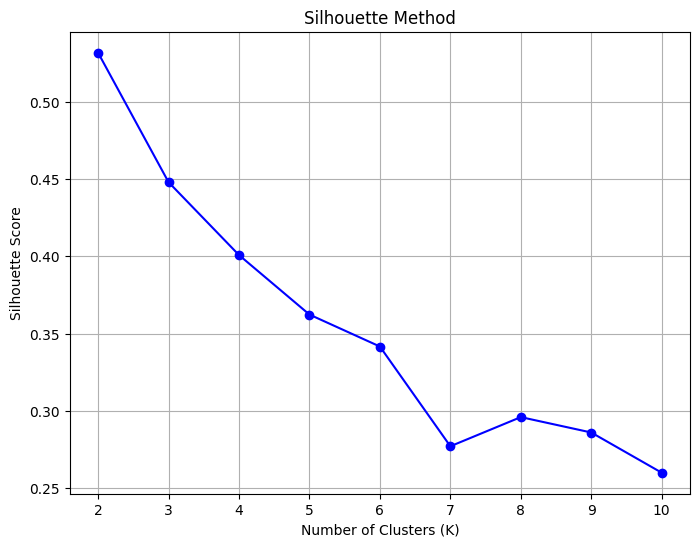

In [248]:
#Create an array to store silhouette scores for different values of K

silhouette_scores = []

#Run K-means clustering for a range of K values and calculate the silhouette score for each K:

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_std)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(df_std, labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [249]:
# Assuming 'df_std_distance' is your standardized data and '4' is the optimal number of clusters
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(df_std)
labels = kmeans.labels_

In [250]:
silhouette_values = silhouette_samples(df_std, labels)
silhouette_values

array([ 0.48603732,  0.49097498,  0.38692542,  0.49460226,  0.27849282,
        0.53135897,  0.12941654,  0.55374592, -0.02243465,  0.5646058 ,
        0.5344848 ,  0.42017676,  0.2288315 ,  0.2338892 ,  0.58826393,
        0.43541025,  0.13806011,  0.56969502,  0.27581027,  0.48704023,
        0.53220637,  0.52090979,  0.51895225,  0.49181489,  0.54523679,
        0.4367971 ,  0.4562217 ,  0.4444506 ,  0.36278312,  0.45463031,
        0.50820612,  0.5219239 ,  0.3473958 ,  0.51979031,  0.11879955,
        0.33699685,  0.31048348,  0.49391892,  0.21691883,  0.56543247,
        0.26500195,  0.55700371,  0.24928177,  0.53206433,  0.21702405,
        0.37404727,  0.47814562,  0.59534113,  0.040084  ,  0.5273171 ,
        0.28366401,  0.5879321 ,  0.06161732,  0.53178275,  0.29832574,
        0.54861588,  0.31784734,  0.4894033 ,  0.46697307,  0.55791964,
        0.03230836,  0.55843261,  0.25801457,  0.51802877,  0.23629805,
        0.47697413,  0.24093955,  0.52047691,  0.0668115 ,  0.52

C:\Users\pablo\AppData\Local\Temp\ipykernel_36076\3680482490.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap("Spectral")(float(i) / 4)


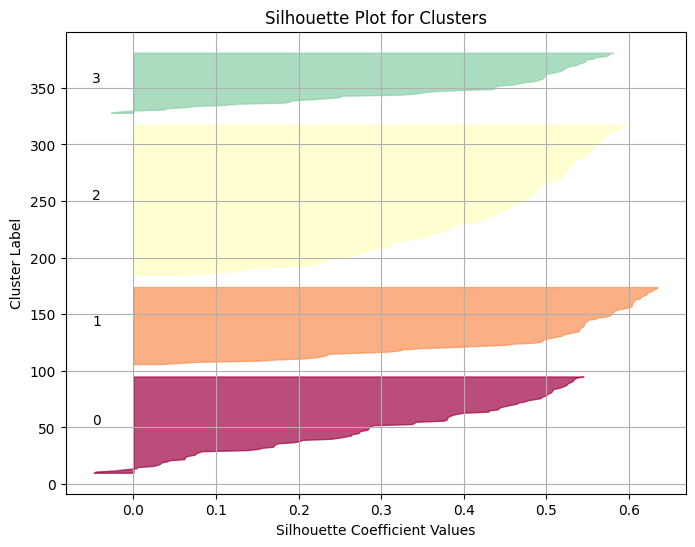

In [251]:
plt.figure(figsize=(8, 6))

y_lower = 10
for i in range(4):
    ith_cluster_silhouette_values = silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.get_cmap("Spectral")(float(i) / 4)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.title("Silhouette Plot for Clusters")
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.grid(True)
plt.show()